Dipole tilt angle: -2.98 degrees
Meridional plane grid (GSM): (40, 50)
Equatorial plane grid (SM z=0; computed in GSM): (60, 60)
Calculating directional derivatives (Meridional plane, GSM grid)...
Curvature range (mer): 0.000 to 7.617 1/Re
Torsion   range (mer): 0.000e+00 to 0.000e+00 1/Re

Antisymmetry verification (Meridional; max errors):
κ_check              = 1.14e-03
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 7.42e-04
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 2.50e-07
dn_db_T_check        = 0.00e+00
db_db_T_check        = 8.57e-06


/tmp/ipykernel_12842/1917891400.py:381: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)


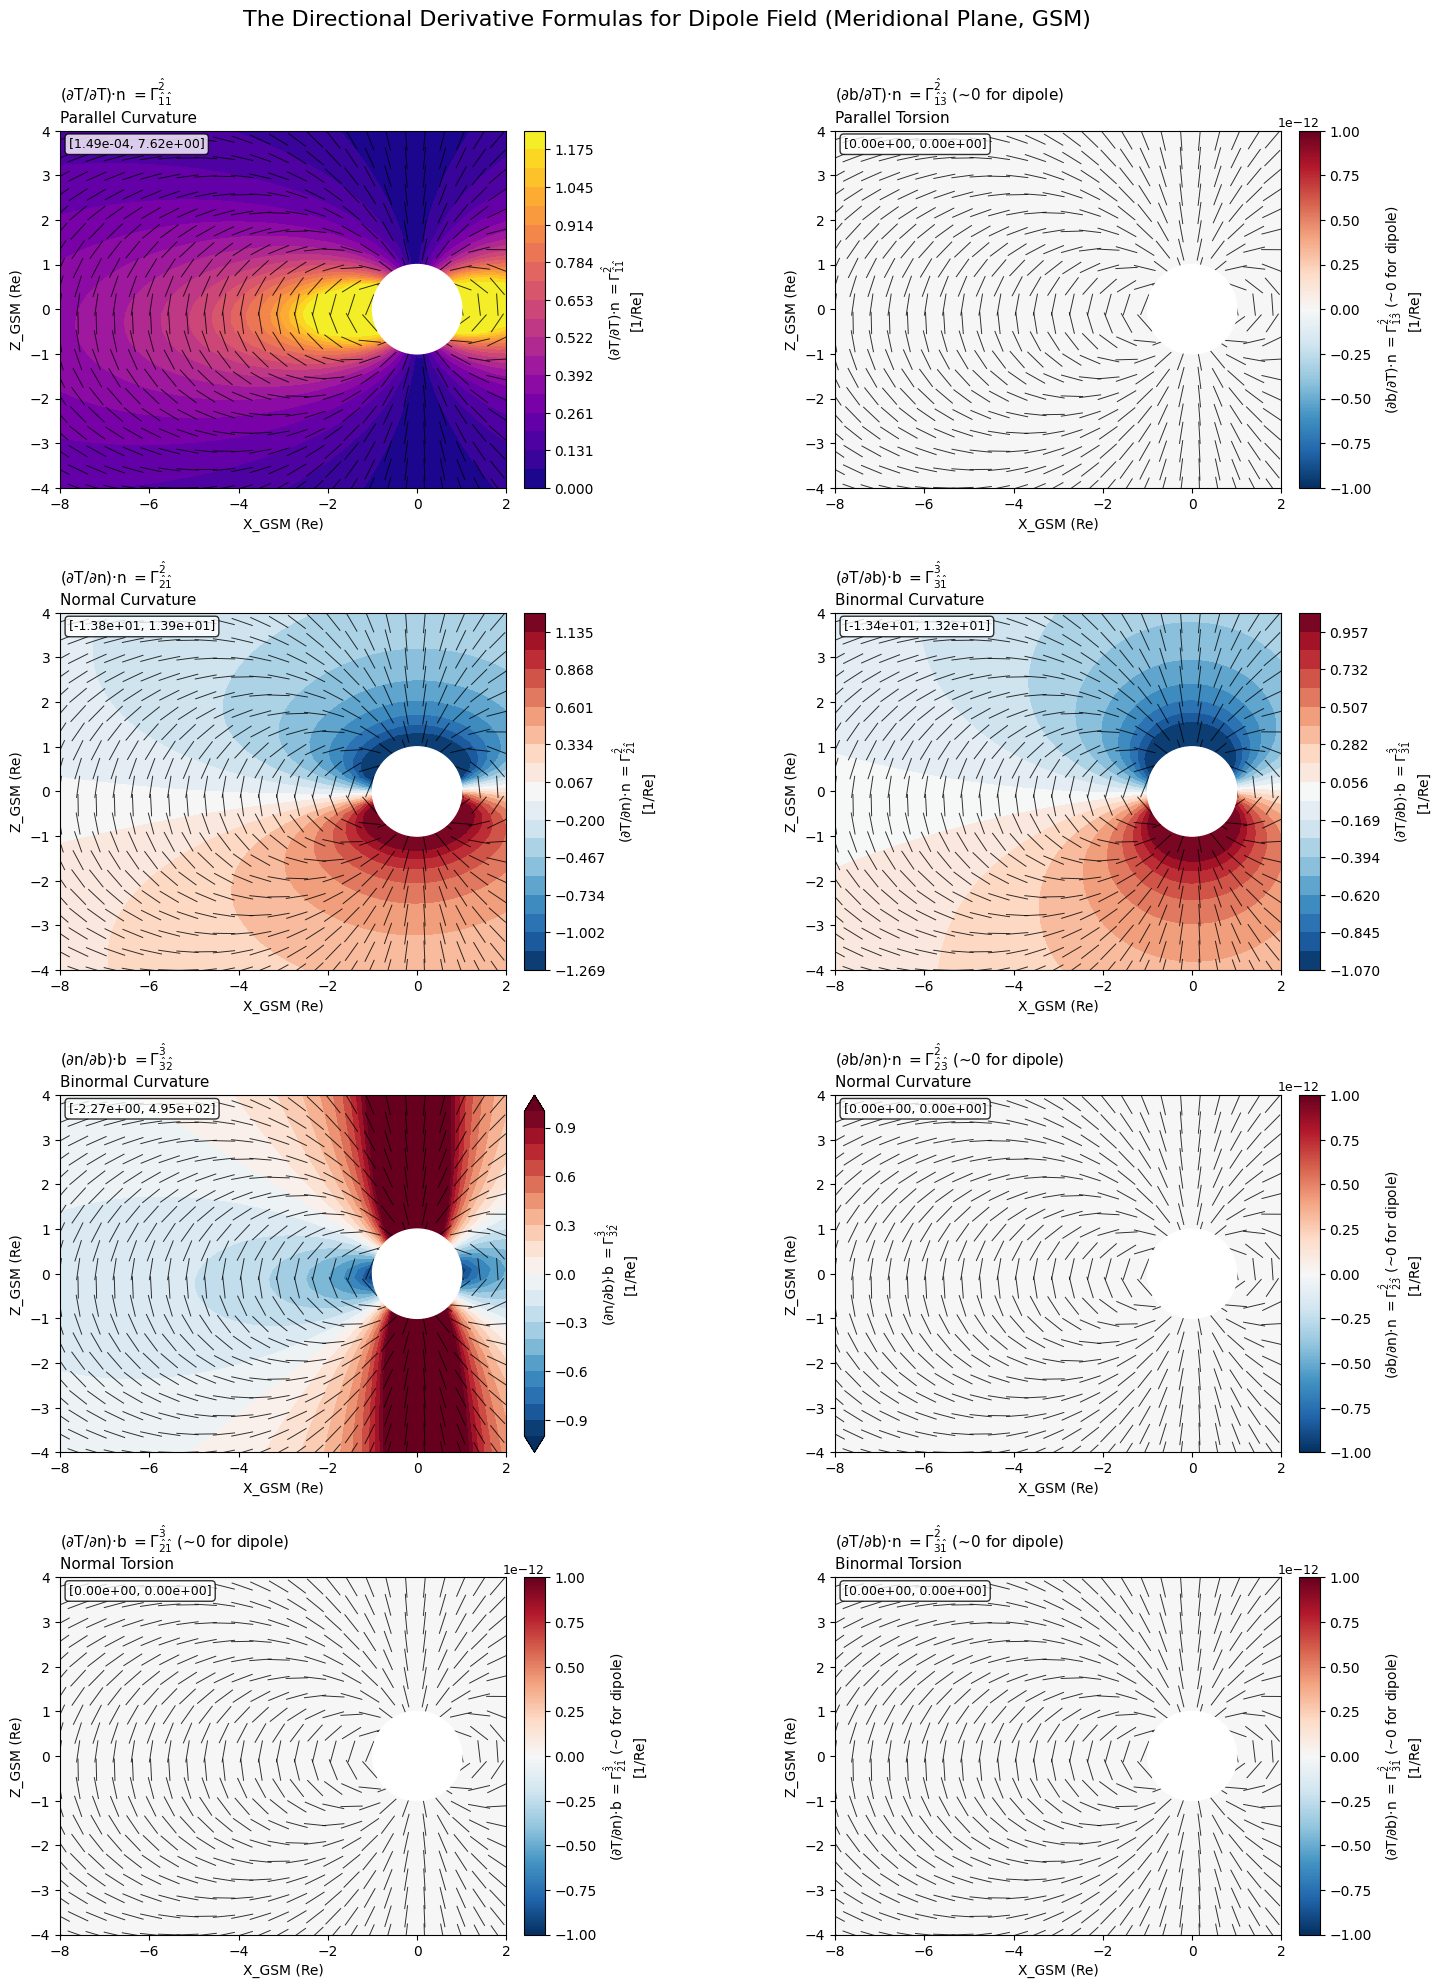

Calculating directional derivatives (Magnetic equator: SM z=0 grid, evaluated in GSM coords)...
Curvature range (eq): 0.234 to 16.434 1/Re
Torsion   range (eq): -4.871e-07 to 4.871e-07 1/Re

Antisymmetry verification (Magnetic equator; max errors):
κ_check              = 3.93e-06
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 0.00e+00
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 8.92e-12
dn_db_T_check        = 0.00e+00
db_db_T_check        = 0.00e+00


/tmp/ipykernel_12842/1917891400.py:460: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)


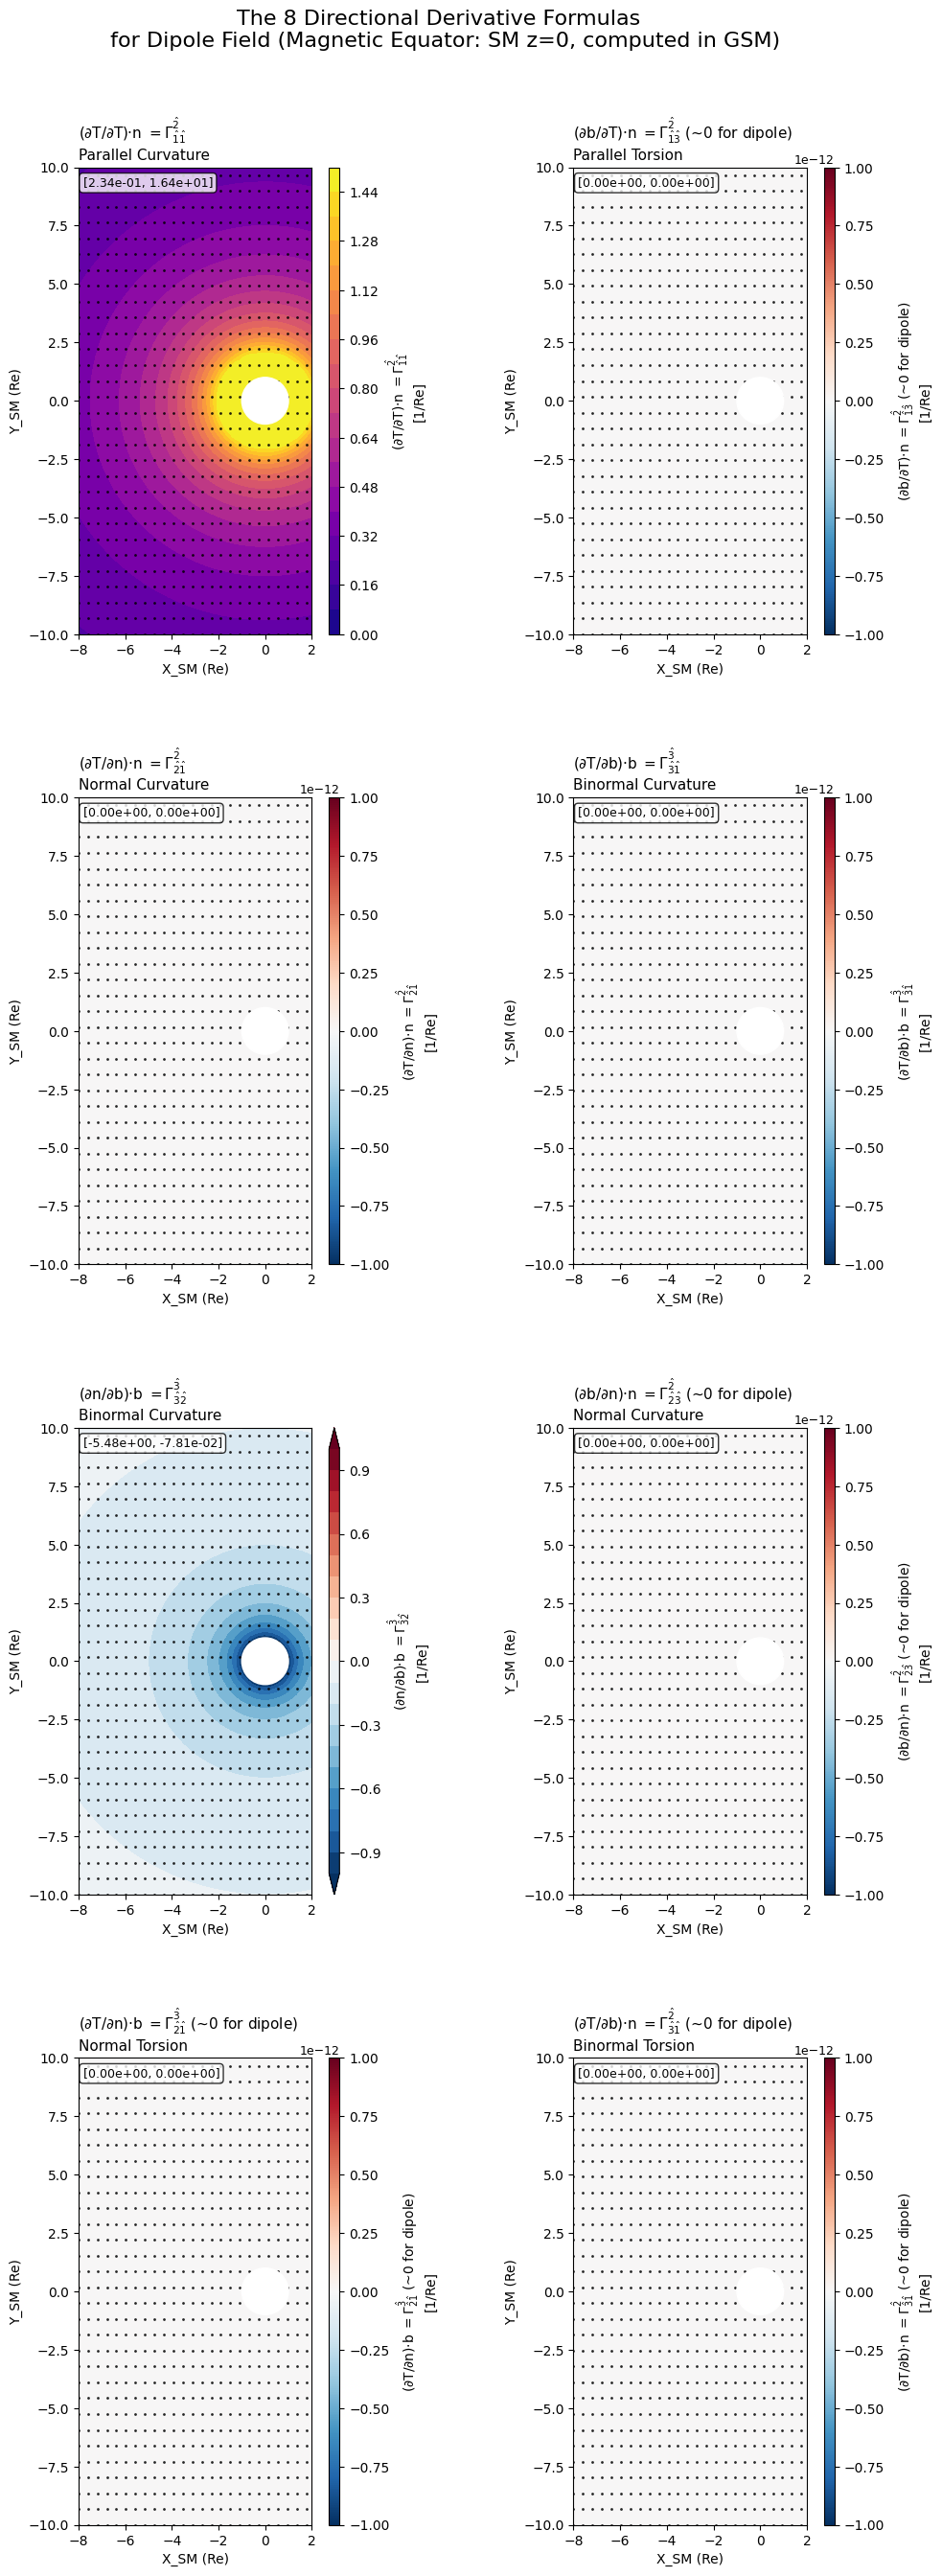

In [31]:
# ============================================================
# Dipole Field Analysis Using the 9 Directional Derivative Formulas
#
# Implemented requirements:
#  - Meridional plane: compute on GSM grid (Y_GSM=0)
#  - Equatorial plane: build grid on SM magnetic equator (Z_SM=0),
#    transform grid points SM→GSM, compute there, then plot on SM plane.
#
# Overlay:
#  - Micro segments in the plotting plane
#  - If nearly perpendicular to the plotting plane, plot a small round dot
#
# Layout fixes:
#  - Avoid overlap between colorbar exponent text and axis title
#    by left-aligning / wrapping title and increasing colorbar pad
#  - Reduce excessive top whitespace by tuning suptitle(y) and tight_layout(rect, h_pad)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable

from geopack import recalc, dip
from geopack.coordinates_vectorized import smgsm_vectorized
from geopack.vectorized import (
    field_line_directional_derivatives_vectorized,
    verify_antisymmetry_relations,
    get_curvature_torsion_from_derivatives,
)

# -------------------------
# User-tunable parameters
# -------------------------
delta_min = 1e-5   # small-value clipping for derivative fields
L0 = 0.5           # segment length scale (Re)
step = 2           # subsampling for overlay density

perp_thresh = 0.05  # |B_in_plane|/|B| < this -> dot instead of segment
dot_size = 4
dot_alpha = 0.85

# Layout knobs
CBAR_PAD = 0.18      # increased from 0.05 to avoid overlaps with titles
CBAR_SIZE = "4.5%"   # colorbar width
TITLE_FONTSIZE = 11  # slightly smaller
SUPTITLE_Y = 0.992   # raise suptitle
TIGHT_RECT_TOP = 0.962
TIGHT_HPAD = 1.2
TIGHT_WPAD = 0.9

# -------------------------
# Utilities
# -------------------------
def get_max_error(error_val):
    if hasattr(error_val, "shape"):
        return np.nanmax(np.abs(error_val))
    return abs(error_val)

def robust_vmin_vmax(data, param_name):
    """Return (vmin, vmax) suitable for stable plotting."""
    data = np.asarray(data)

    if param_name == "dT_dT_n":  # curvature: non-negative
        vmax = np.nanpercentile(data, 95)
        if (not np.isfinite(vmax)) or (vmax <= 0):
            vmax = np.nanmax(data)
        if (not np.isfinite(vmax)) or (vmax <= 0):
            vmax = 1e-12
        vmin = 0.0
        return vmin, vmax

    vmax = np.nanpercentile(np.abs(data), 95)
    if (not np.isfinite(vmax)) or (vmax <= 0):
        vmax = np.nanmax(np.abs(data))
    if (not np.isfinite(vmax)) or (vmax <= 0):
        vmax = 1e-12
    vmin = -vmax
    return vmin, vmax

def plot_scalar_on_grid(ax, X, Y, data, cmap, param_name, force_levels=None):
    """
    Safe plotting helper:
      - uses contourf when range exists,
      - falls back to imshow when data is (almost) constant,
      - guarantees increasing contour levels.
    Returns mappable for colorbar.
    """
    data = np.asarray(data)

    if force_levels is not None:
        levels = force_levels
        return ax.contourf(X, Y, data, levels=levels, cmap=cmap, extend="both")

    vmin, vmax = robust_vmin_vmax(data, param_name)

    dmin = np.nanmin(data)
    dmax = np.nanmax(data)
    if (not np.isfinite(dmin)) or (not np.isfinite(dmax)) or (abs(dmax - dmin) < 1e-14):
        extent = (np.nanmin(X), np.nanmax(X), np.nanmin(Y), np.nanmax(Y))
        im = ax.imshow(
            data,
            origin="lower",
            extent=extent,
            aspect="equal",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        return im

    if vmax <= vmin:
        eps = 1e-12 if vmin == 0 else abs(vmin) * 1e-6 + 1e-12
        vmin -= eps
        vmax += eps

    levels = np.linspace(vmin, vmax, 20)
    data_for_plot = np.clip(data, vmin, vmax)
    return ax.contourf(X, Y, data_for_plot, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)

UNIT_STR = "1/Re"   # 例: "1/Re" あるいは r"1/R$_E$"
def add_colorbar(fig, ax, im, label, unit=UNIT_STR):
    """Colorbar with a bit more pad so exponent text doesn't collide with titles."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=CBAR_SIZE, pad=CBAR_PAD)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(f"{label}\n[{unit}]", fontsize=10)

    # Make offset/exponent text smaller (still readable)
    try:
        cbar.ax.yaxis.get_offset_text().set_fontsize(9)
    except Exception:
        pass

    return cbar

def set_panel_title(ax, formula, title):
    """
    Avoid overlap by:
      - left-aligning
      - splitting into 2 lines (formula + title)
    """
    ax.set_title(f"{formula}\n{title}", fontsize=TITLE_FONTSIZE, loc="left", pad=6)
    # Ensure multi-line alignment really stays left
    ax.title.set_multialignment("left")

def build_overlay_segments_and_dots_meridional(X, Z, Y0):
    """
    Meridional GSM X-Z plane (Y=0):
      - segments aligned with in-plane component (Bx, Bz)
      - dots when in-plane component is tiny vs |B|
    Returns: segments (N,2,2) or None, dot_x, dot_z
    """
    Bx, By, Bz = dip(X, Y0, Z)

    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)
    Bmag[Bmag == 0] = np.nan

    Bin = np.sqrt(Bx**2 + Bz**2)   # in-plane magnitude
    ratio = Bin / Bmag

    Bin_safe = Bin.copy()
    Bin_safe[Bin_safe == 0] = np.nan

    dx = L0 * Bx / Bin_safe
    dz = L0 * Bz / Bin_safe

    Xs = X[::step, ::step]
    Zs = Z[::step, ::step]
    dxs = dx[::step, ::step]
    dzs = dz[::step, ::step]
    rs = ratio[::step, ::step]

    finite = np.isfinite(dxs) & np.isfinite(dzs) & np.isfinite(rs)

    mask_line = finite & (rs >= perp_thresh)
    mask_dot  = finite & (rs <  perp_thresh)

    if np.any(mask_line):
        x0 = Xs[mask_line] - dxs[mask_line] / 2.0
        z0 = Zs[mask_line] - dzs[mask_line] / 2.0
        x1 = Xs[mask_line] + dxs[mask_line] / 2.0
        z1 = Zs[mask_line] + dzs[mask_line] / 2.0
        segments = np.stack(
            [np.stack([x0, z0], axis=-1), np.stack([x1, z1], axis=-1)],
            axis=1
        )
    else:
        segments = None

    dot_x = Xs[mask_dot]
    dot_z = Zs[mask_dot]
    return segments, dot_x, dot_z

def build_overlay_segments_and_dots_equator_sm(X_sm, Y_sm, X_gsm, Y_gsm, Z_gsm):
    """
    Magnetic equator plot on SM X-Y plane:
      - compute B at GSM points on that surface
      - rotate vector GSM→SM
      - segments from in-plane (Bx_sm, By_sm)
      - dots when |B_in_plane|/|B| is tiny
    Returns: segments (N,2,2) or None, dot_x, dot_y
    """
    Bx_g, By_g, Bz_g = dip(X_gsm, Y_gsm, Z_gsm)
    Bx_s, By_s, Bz_s = smgsm_vectorized(Bx_g, By_g, Bz_g, j=-1)

    Bmag = np.sqrt(Bx_s**2 + By_s**2 + Bz_s**2)
    Bmag[Bmag == 0] = np.nan

    Bxy = np.sqrt(Bx_s**2 + By_s**2)
    ratio = Bxy / Bmag

    Bxy_safe = Bxy.copy()
    Bxy_safe[Bxy_safe == 0] = np.nan

    dx = np.full_like(Bx_s, np.nan, dtype=float)
    dy = np.full_like(By_s, np.nan, dtype=float)

    mask_line_full = np.isfinite(ratio) & (ratio >= perp_thresh) & np.isfinite(Bxy_safe)
    dx[mask_line_full] = L0 * Bx_s[mask_line_full] / Bxy_safe[mask_line_full]
    dy[mask_line_full] = L0 * By_s[mask_line_full] / Bxy_safe[mask_line_full]

    Xs = X_sm[::step, ::step]
    Ys = Y_sm[::step, ::step]
    dxs = dx[::step, ::step]
    dys = dy[::step, ::step]
    rs  = ratio[::step, ::step]

    finite = np.isfinite(rs)

    mask_line = finite & (rs >= perp_thresh) & np.isfinite(dxs) & np.isfinite(dys)
    mask_dot  = finite & (rs <  perp_thresh)

    if np.any(mask_line):
        x0 = Xs[mask_line] - dxs[mask_line] / 2.0
        y0 = Ys[mask_line] - dys[mask_line] / 2.0
        x1 = Xs[mask_line] + dxs[mask_line] / 2.0
        y1 = Ys[mask_line] + dys[mask_line] / 2.0
        segments = np.stack(
            [np.stack([x0, y0], axis=-1), np.stack([x1, y1], axis=-1)],
            axis=1
        )
    else:
        segments = None

    dot_x = Xs[mask_dot]
    dot_y = Ys[mask_dot]
    return segments, dot_x, dot_y

# -------------------------
# Set up time (dipole tilt)
# -------------------------
ut = 5000.0 + 90.0 * 24.0 * 60.0 * 60.0
ps = recalc(ut)
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

# -------------------------
# Create grids
# -------------------------
# Meridional plane (GSM): X-Z at Y=0
x_mer = np.linspace(-8, 2, 50)
z_mer = np.linspace(-4, 4, 40)
X_mer, Z_mer = np.meshgrid(x_mer, z_mer)
Y_mer = np.zeros_like(X_mer)

# Magnetic equator (SM): Z_SM=0
x_sm = np.linspace(-8, 4, 60)
y_sm = np.linspace(-10, 10, 60)
X_sm, Y_sm = np.meshgrid(x_sm, y_sm)
Z_sm = np.zeros_like(X_sm)

# SM -> GSM for computation on magnetic equator
X_eq_gsm, Y_eq_gsm, Z_eq_gsm = smgsm_vectorized(X_sm, Y_sm, Z_sm, j=+1)

# Flatten
x_mer_flat = X_mer.ravel()
y_mer_flat = Y_mer.ravel()
z_mer_flat = Z_mer.ravel()

x_eq_flat = X_eq_gsm.ravel()
y_eq_flat = Y_eq_gsm.ravel()
z_eq_flat = Z_eq_gsm.ravel()

print(f"Meridional plane grid (GSM): {X_mer.shape}")
print(f"Equatorial plane grid (SM z=0; computed in GSM): {X_sm.shape}")

# -------------------------
# Dipole wrapper
# -------------------------
def dipole_field_wrapper(parmod, ps_in, x, y, z):
    bx, by, bz = dip(x, y, z)
    return bx, by, bz

# Keys
main_keys = [
    'dT_dT_n', 'dT_dT_b', 'dn_dT_b', 'dT_dn_n', 'dT_dn_b',
    'dn_dn_b', 'dn_db_b', 'dn_db_T', 'db_db_T'
]
anti_keys = [
    'dn_dT_T', 'db_dT_T', 'db_dT_n', 'dn_dn_T', 'db_dn_T',
    'db_dn_n', 'db_db_n', 'dT_db_n', 'dT_db_b'
]

# 8 panels
plot_info = [
    ('dT_dT_n', '(∂T/∂T)·n $=\\Gamma^{\\hat{2}}_{\\hat{1}\\hat{1}}$', 'Parallel Curvature', 'plasma'),
    ('db_dT_n', '(∂b/∂T)·n $=\\Gamma^{\\hat{2}}_{\\hat{1}\\hat{3}}$ (~0 for dipole)', 'Parallel Torsion ', 'RdBu_r'),
    ('dT_dn_n', '(∂T/∂n)·n $=\\Gamma^{\\hat{2}}_{\\hat{2}\\hat{1}}$', 'Normal Curvature', 'RdBu_r'),
    ('dT_db_b', '(∂T/∂b)·b $=\\Gamma^{\\hat{3}}_{\\hat{3}\\hat{1}}$', 'Binormal Curvature', 'RdBu_r'),
    ('dn_db_b', '(∂n/∂b)·b $=\\Gamma^{\\hat{3}}_{\\hat{3}\\hat{2}}$', 'Binormal Curvature', 'RdBu_r'),
    ('db_dn_n', '(∂b/∂n)·n $=\\Gamma^{\\hat{2}}_{\\hat{2}\\hat{3}}$ (~0 for dipole)', 'Normal Curvature ', 'RdBu_r'),
    ('dT_dn_b', '(∂T/∂n)·b $=\\Gamma^{\\hat{3}}_{\\hat{2}\\hat{1}}$ (~0 for dipole)', 'Normal Torsion ', 'RdBu_r'),
    ('dT_db_n', '(∂T/∂b)·n $=\\Gamma^{\\hat{2}}_{\\hat{3}\\hat{1}}$ (~0 for dipole)', 'Binormal Torsion ', 'RdBu_r')
]

# ============================================================
# 1) MERIDIONAL PLANE (GSM grid)
# ============================================================
print("Calculating directional derivatives (Meridional plane, GSM grid)...")
derivatives_mer = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps,
    x_mer_flat, y_mer_flat, z_mer_flat,
    delta=1e-5
)

curvature_mer, torsion_mer = get_curvature_torsion_from_derivatives(derivatives_mer)
print(f"Curvature range (mer): {np.nanmin(curvature_mer):.3f} to {np.nanmax(curvature_mer):.3f} 1/Re")
print(f"Torsion   range (mer): {np.nanmin(torsion_mer):.3e} to {np.nanmax(torsion_mer):.3e} 1/Re")

params_mer = {}
for key in main_keys + anti_keys:
    arr = derivatives_mer[key].reshape(X_mer.shape)
    arr[np.abs(arr) < delta_min] = 0
    params_mer[key] = arr

errors_mer = verify_antisymmetry_relations(derivatives_mer)
print("\nAntisymmetry verification (Meridional; max errors):")
for name, err in errors_mer.items():
    print(f"{name:20} = {get_max_error(err):.2e}")

segments_mer, dot_x_mer, dot_z_mer = build_overlay_segments_and_dots_meridional(X_mer, Z_mer, Y_mer)

# Plot meridional (8 panels)
fig = plt.figure(figsize=(18, 22))
gs = GridSpec(4, 2, figure=fig, hspace=0.35, wspace=0.25)

for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    data = params_mer[param_name]

    if param_name == 'dn_db_b':
        im = plot_scalar_on_grid(
            ax, X_mer, Z_mer, data, cmap, param_name,
            force_levels=np.linspace(-1, 1, 21)
        )
    else:
        im = plot_scalar_on_grid(ax, X_mer, Z_mer, data, cmap, param_name)

    if segments_mer is not None:
        ax.add_collection(LineCollection(segments_mer, colors='k', linewidths=0.7, alpha=0.8))
    if dot_x_mer.size > 0:
        ax.scatter(dot_x_mer, dot_z_mer, s=dot_size, marker='o', c='k',
                   alpha=dot_alpha, linewidths=0)

    ax.add_patch(plt.Circle((0, 0), 1, color='white', zorder=10))
    ax.set_xlabel('X_GSM (Re)')
    ax.set_ylabel('Z_GSM (Re)')
    set_panel_title(ax, formula, title)
    ax.set_aspect('equal')

    add_colorbar(fig, ax, im, formula)

    ax.text(
        0.02, 0.98, f"[{np.nanmin(data):.2e}, {np.nanmax(data):.2e}]",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# 1) まずは全部（サブプロット＋カラーバー）を詰める
fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)

# 2) 「図全体の上端」をどこまで使うかを直接指定（ここが空白の効き所）
fig.subplots_adjust(top=0.93)   # 0.92〜0.96あたりで好みに調整

# 3) 最後に全体タイトル（tight_layoutに余白を二重計算させない）
fig.suptitle('The Directional Derivative Formulas for Dipole Field (Meridional Plane, GSM)',
             fontsize=16, y=0.985)

plt.show()

# ============================================================
# 2) EQUATORIAL PLANE = MAGNETIC EQUATOR (SM grid -> compute in GSM)
# ============================================================
print("Calculating directional derivatives (Magnetic equator: SM z=0 grid, evaluated in GSM coords)...")
derivatives_eq = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps,
    x_eq_flat, y_eq_flat, z_eq_flat,
    delta=1e-5
)

curvature_eq, torsion_eq = get_curvature_torsion_from_derivatives(derivatives_eq)
print(f"Curvature range (eq): {np.nanmin(curvature_eq):.3f} to {np.nanmax(curvature_eq):.3f} 1/Re")
print(f"Torsion   range (eq): {np.nanmin(torsion_eq):.3e} to {np.nanmax(torsion_eq):.3e} 1/Re")

params_eq = {}
for key in main_keys + anti_keys:
    arr = derivatives_eq[key].reshape(X_sm.shape)
    arr[np.abs(arr) < delta_min] = 0
    params_eq[key] = arr

errors_eq = verify_antisymmetry_relations(derivatives_eq)
print("\nAntisymmetry verification (Magnetic equator; max errors):")
for name, err in errors_eq.items():
    print(f"{name:20} = {get_max_error(err):.2e}")

segments_eq, dot_x_eq, dot_y_eq = build_overlay_segments_and_dots_equator_sm(
    X_sm, Y_sm, X_eq_gsm, Y_eq_gsm, Z_eq_gsm
)

# Plot magnetic equator (8 panels)
fig = plt.figure(figsize=(12, 30))
gs = GridSpec(4, 2, figure=fig, hspace=0.35, wspace=0.25)
axes = [fig.add_subplot(gs[r, c]) for r in range(4) for c in range(2)]

for idx, (param_name, formula, title, cmap) in enumerate(plot_info):
    ax = axes[idx]
    data = params_eq[param_name]

    if param_name == 'dn_db_b':
        im = plot_scalar_on_grid(
            ax, X_sm, Y_sm, data, cmap, param_name,
            force_levels=np.linspace(-1, 1, 21)
        )
    else:
        im = plot_scalar_on_grid(ax, X_sm, Y_sm, data, cmap, param_name)

    if segments_eq is not None:
        ax.add_collection(LineCollection(segments_eq, colors='k', linewidths=0.7, alpha=0.8))
    if dot_x_eq.size > 0:
        ax.scatter(dot_x_eq, dot_y_eq, s=dot_size, marker='o', c='k',
                   alpha=dot_alpha, linewidths=0)

    ax.add_patch(plt.Circle((0, 0), 1, color='white', zorder=10))
    ax.set_xlabel('X_SM (Re)')
    ax.set_ylabel('Y_SM (Re)')
    set_panel_title(ax, formula, title)
    ax.set_aspect('equal')
    ax.set_xlim(-8, 2)

    add_colorbar(fig, ax, im, formula)

    ax.text(
        0.02, 0.98, f"[{np.nanmin(data):.2e}, {np.nanmax(data):.2e}]",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# 1) まずは全部（サブプロット＋カラーバー）を詰める
fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)

# 2) 「図全体の上端」をどこまで使うかを直接指定（ここが空白の効き所）
fig.subplots_adjust(top=0.93)   # 0.92〜0.96あたりで好みに調整

# 3) 最後に全体タイトル（tight_layoutに余白を二重計算させない）
fig.suptitle('The 8 Directional Derivative Formulas \n for Dipole Field (Magnetic Equator: SM z=0, computed in GSM)',
             fontsize=16, y=0.985)

plt.show()


 ## Verify Key Relationships  (style matched to the first two plot blocks)

/tmp/ipykernel_12842/2353826165.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)


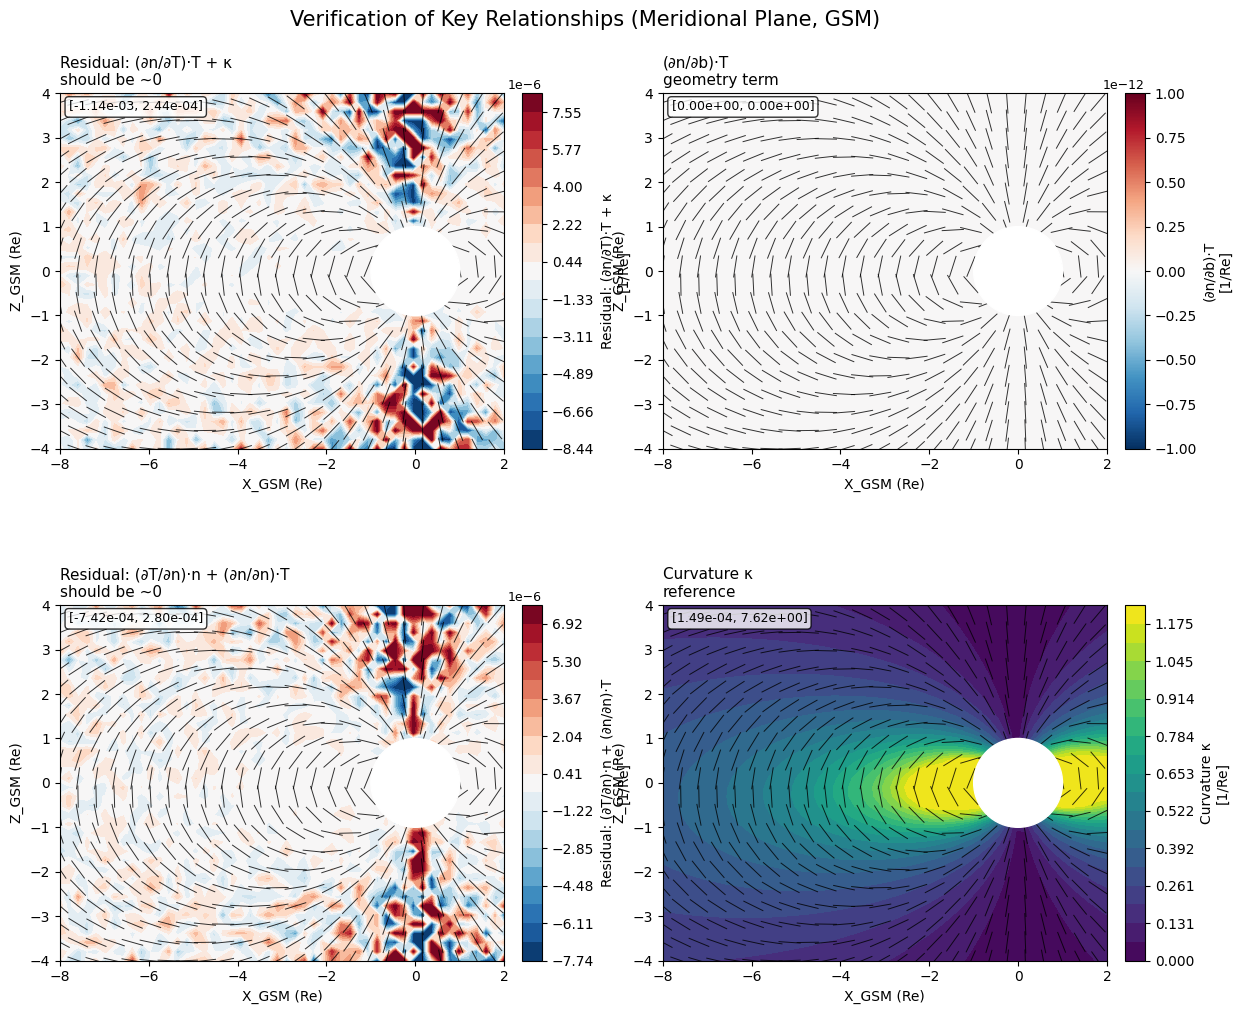

Quantitative Verification:
max |(∂n/∂T)·T + κ|               = 1.144e-03
max |(∂n/∂b)·T|                   = 0.000e+00
max |(∂T/∂n)·n + (∂n/∂n)·T|       = 7.421e-04
max |κ|                            = 7.617
max |τ|                            = 0.000e+00


In [32]:
# ---- Safety: make sure grids exist ----
# curvature/torsion grids (if not already created as grids)
if "curvature_mer_grid" not in globals():
    try:
        curvature_mer_grid = curvature_mer.reshape(X_mer.shape)
    except Exception:
        curvature_mer_grid = None

if "torsion_mer_grid" not in globals():
    try:
        torsion_mer_grid = torsion_mer.reshape(X_mer.shape)
    except Exception:
        torsion_mer_grid = None

# if overlays not available, rebuild (using your functions)
if "segments_mer" not in globals() or "dot_x_mer" not in globals() or "dot_z_mer" not in globals():
    segments_mer, dot_x_mer, dot_z_mer = build_overlay_segments_and_dots_meridional(X_mer, Z_mer, Y_mer)

# ---- Relationship maps on meridional plane (GSM X-Z) ----
# (∂n/∂T)·T + κ  ~ 0
diff1 = params_mer["dn_dT_T"] + curvature_mer_grid

# (∂n/∂b)·T  (geometry-related)
map2 = params_mer["dn_db_T"]

# (∂T/∂n)·n + (∂n/∂n)·T  ~ 0
antisym1 = params_mer["dT_dn_n"] + params_mer["dn_dn_T"]

# κ for reference
kappa_map = curvature_mer_grid

# ---- Plot (2x2), using same contourf rules + same overlay (segments/dots) ----
fig = plt.figure(figsize=(14, 11))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]

panels = [
    ("Residual: (∂n/∂T)·T + κ", "should be ~0", diff1, "RdBu_r", "residual"),
    ("(∂n/∂b)·T", "geometry term", map2, "RdBu_r", "residual"),
    ("Residual: (∂T/∂n)·n + (∂n/∂n)·T", "should be ~0", antisym1, "RdBu_r", "residual"),
    ("Curvature κ", "reference", kappa_map, "viridis", "dT_dT_n"),
]

for ax, (formula, title, data, cmap, pname) in zip(axes, panels):
    im = plot_scalar_on_grid(ax, X_mer, Z_mer, data, cmap, pname)

    # overlay micro segments + dots (same as your first plot)
    if segments_mer is not None:
        ax.add_collection(LineCollection(segments_mer, colors='k', linewidths=0.7, alpha=0.8))
    if dot_x_mer.size > 0:
        ax.scatter(dot_x_mer, dot_z_mer, s=dot_size, marker='o', c='k',
                   alpha=dot_alpha, linewidths=0)

    ax.add_patch(plt.Circle((0, 0), 1, color='white', zorder=10))
    ax.set_xlabel("X_GSM (Re)")
    ax.set_ylabel("Z_GSM (Re)")
    set_panel_title(ax, formula, title)
    ax.set_aspect("equal")

    add_colorbar(fig, ax, im, formula)

    ax.text(
        0.02, 0.98, f"[{np.nanmin(data):.2e}, {np.nanmax(data):.2e}]",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)
fig.subplots_adjust(top=0.92)
fig.suptitle("Verification of Key Relationships (Meridional Plane, GSM)", fontsize=15, y=0.985)
plt.show()

# ---- Quantitative verification ----
print("Quantitative Verification:")
print("=" * 60)
print(f"max |(∂n/∂T)·T + κ|               = {np.nanmax(np.abs(diff1)):.3e}")
print(f"max |(∂n/∂b)·T|                   = {np.nanmax(np.abs(map2)):.3e}")
print(f"max |(∂T/∂n)·n + (∂n/∂n)·T|       = {np.nanmax(np.abs(antisym1)):.3e}")
if curvature_mer_grid is not None:
    print(f"max |κ|                            = {np.nanmax(np.abs(curvature_mer_grid)):.3f}")
if torsion_mer_grid is not None:
    print(f"max |τ|                            = {np.nanmax(np.abs(torsion_mer_grid)):.3e}")




## Additional Antisymmetry Sums (side-by-side)

/tmp/ipykernel_12842/142551712.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)


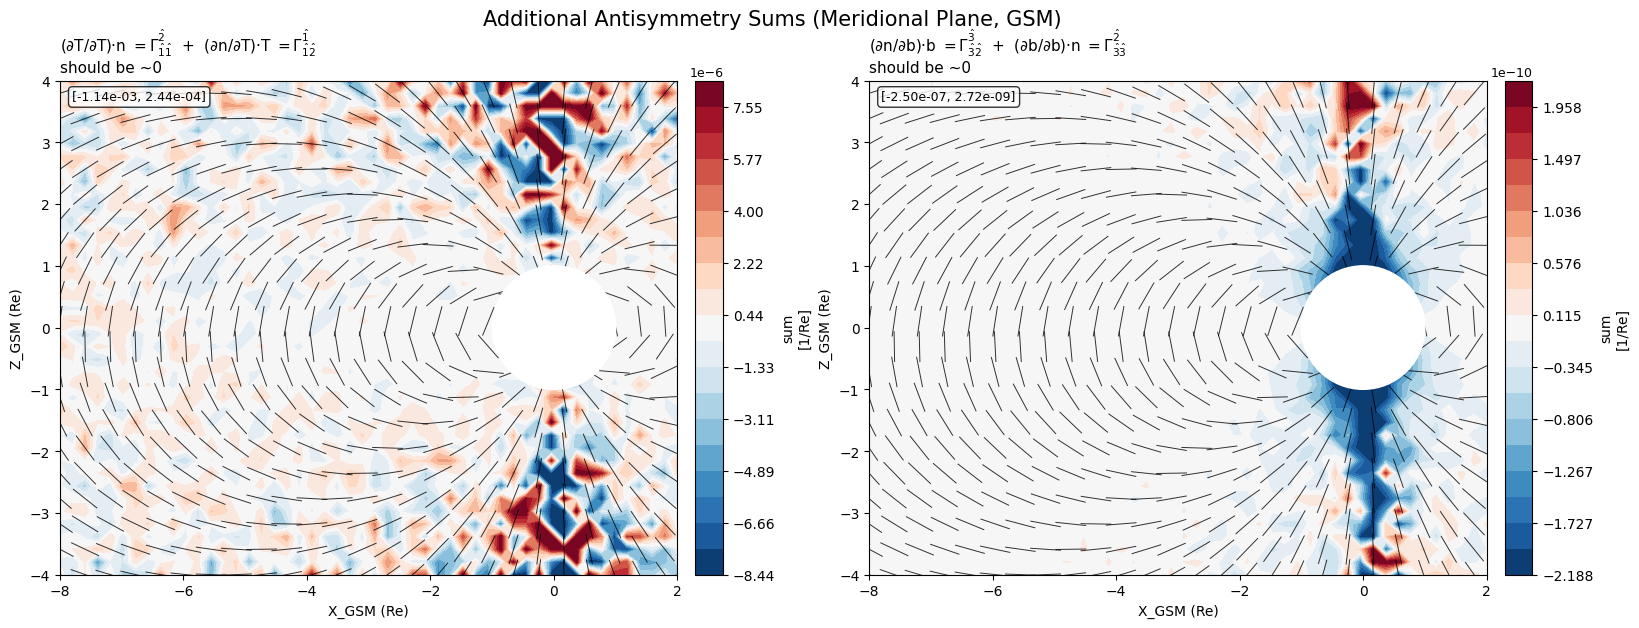

Additional Antisymmetry Sums (Meridional) — max abs:
max |dT_dT_n + dn_dT_T|   = 1.144e-03
max |dn_db_b + db_db_n|   = 2.500e-07


In [39]:
# ---- safety: overlays exist? (meridional) ----
if "segments_mer" not in globals() or "dot_x_mer" not in globals() or "dot_z_mer" not in globals():
    segments_mer, dot_x_mer, dot_z_mer = build_overlay_segments_and_dots_meridional(X_mer, Z_mer, Y_mer)

# ---- sums on meridional plane (GSM X-Z) ----
sum_kappa_mer = params_mer["dT_dT_n"] + params_mer["dn_dT_T"]
sum_bb_mer    = params_mer["dn_db_b"] + params_mer["db_db_n"]

fig = plt.figure(figsize=(19, 6.5))
gs = GridSpec(1, 2, figure=fig, hspace=0.25, wspace=0.22)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

# Panel 1: dT_dT_n + dn_dT_T
ax = axes[0]
im = plot_scalar_on_grid(ax, X_mer, Z_mer, sum_kappa_mer, "RdBu_r", "residual")
if segments_mer is not None:
    ax.add_collection(LineCollection(segments_mer, colors='k', linewidths=0.7, alpha=0.8))
if dot_x_mer.size > 0:
    ax.scatter(dot_x_mer, dot_z_mer, s=dot_size, marker='o', c='k', alpha=dot_alpha, linewidths=0)
ax.add_patch(plt.Circle((0, 0), 1, color='white', zorder=10))
ax.set_xlabel("X_GSM (Re)")
ax.set_ylabel("Z_GSM (Re)")
set_panel_title(
    ax,
    r"(∂T/∂T)·n $=\Gamma^{\hat{2}}_{\hat{1}\hat{1}}$  +  (∂n/∂T)·T $=\Gamma^{\hat{1}}_{\hat{1}\hat{2}}$",
    "should be ~0"
)
ax.set_aspect("equal")
add_colorbar(fig, ax, im, "sum")
ax.text(
    0.02, 0.98, f"[{np.nanmin(sum_kappa_mer):.2e}, {np.nanmax(sum_kappa_mer):.2e}]",
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Panel 2: dn_db_b + db_db_n
ax = axes[1]
im = plot_scalar_on_grid(ax, X_mer, Z_mer, sum_bb_mer, "RdBu_r", "residual")
if segments_mer is not None:
    ax.add_collection(LineCollection(segments_mer, colors='k', linewidths=0.7, alpha=0.8))
if dot_x_mer.size > 0:
    ax.scatter(dot_x_mer, dot_z_mer, s=dot_size, marker='o', c='k', alpha=dot_alpha, linewidths=0)
ax.add_patch(plt.Circle((0, 0), 1, color='white', zorder=10))
ax.set_xlabel("X_GSM (Re)")
ax.set_ylabel("Z_GSM (Re)")
set_panel_title(
    ax,
    r"(∂n/∂b)·b $=\Gamma^{\hat{3}}_{\hat{3}\hat{2}}$  +  (∂b/∂b)·n $=\Gamma^{\hat{2}}_{\hat{3}\hat{3}}$",
    "should be ~0"
)
ax.set_aspect("equal")
add_colorbar(fig, ax, im, "sum")
ax.text(
    0.02, 0.98, f"[{np.nanmin(sum_bb_mer):.2e}, {np.nanmax(sum_bb_mer):.2e}]",
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

fig.tight_layout(h_pad=TIGHT_HPAD, w_pad=TIGHT_WPAD, pad=0.3)
fig.subplots_adjust(top=0.88)
fig.suptitle("Additional Antisymmetry Sums (Meridional Plane, GSM)", fontsize=15, y=0.985)
plt.show()

print("Additional Antisymmetry Sums (Meridional) — max abs:")
print("=" * 60)
print(f"max |dT_dT_n + dn_dT_T|   = {np.nanmax(np.abs(sum_kappa_mer)):.3e}")
print(f"max |dn_db_b + db_db_n|   = {np.nanmax(np.abs(sum_bb_mer)):.3e}")

 ## Analyze Along a Single Field Line (intent kept, coordinates made consistent)

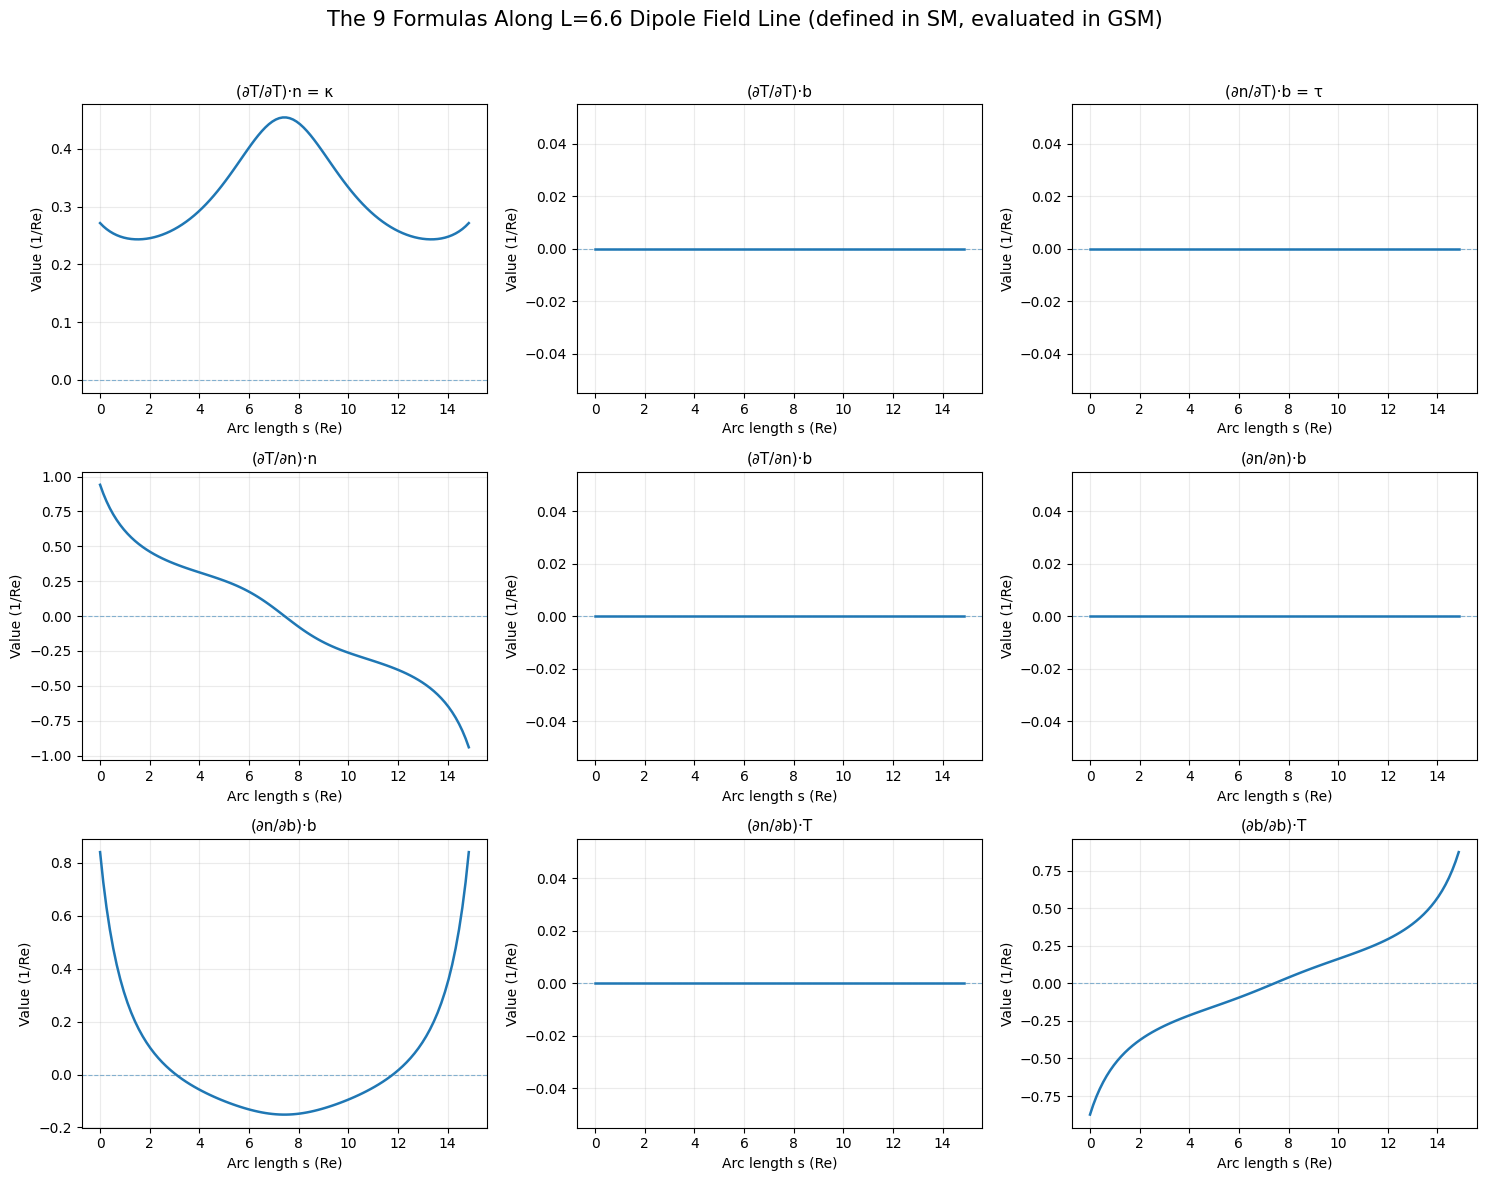


Antisymmetry verification along field line (max errors):
κ_check              = 3.17e-06
τ_check              = 0.00e+00
zero_check_1         = 0.00e+00
dT_dn_n_check        = 3.98e-06
dT_dn_b_check        = 0.00e+00
dn_dn_b_check        = 0.00e+00
dn_db_b_check        = 6.85e-11
dn_db_T_check        = 0.00e+00
db_db_T_check        = 4.32e-11


In [34]:
# For a dipole, field lines follow r = L*cos^2(λ) in SM coordinates.
# We'll define the line in SM, then transform SM→GSM before evaluating derivatives.

L_shell = 6.6
lambda_vals = np.linspace(-60, 60, 100) * np.pi / 180  # magnetic latitude (rad)

# SM coordinates along the field line (meridional plane y_sm=0)
r = L_shell * np.cos(lambda_vals)**2
x_line_sm = -r * np.cos(lambda_vals)
y_line_sm = np.zeros_like(x_line_sm)
z_line_sm =  r * np.sin(lambda_vals)

# Transform to GSM for evaluation
x_line_gsm, y_line_gsm, z_line_gsm = smgsm_vectorized(x_line_sm, y_line_sm, z_line_sm, j=+1)

# Evaluate derivatives along the line (GSM coords)
derivatives_line = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_line_gsm, y_line_gsm, z_line_gsm, delta=1e-5
)

# Arc length (approx) along the *GSM* curve
ds = np.sqrt(np.diff(x_line_gsm)**2 + np.diff(y_line_gsm)**2 + np.diff(z_line_gsm)**2)
s = np.concatenate([[0], np.cumsum(ds)])

# 3x3 plot of the 9 formulas (keeping your original intent)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'The 9 Formulas Along L={L_shell} Dipole Field Line (defined in SM, evaluated in GSM)', fontsize=15)

plot_data = [
    ('dT_dT_n',  '(∂T/∂T)·n = κ'),
    ('dT_dT_b',  '(∂T/∂T)·b'),
    ('dn_dT_b',  '(∂n/∂T)·b = τ'),
    ('dT_dn_n',  '(∂T/∂n)·n'),
    ('dT_dn_b',  '(∂T/∂n)·b'),
    ('dn_dn_b',  '(∂n/∂n)·b'),
    ('dn_db_b',  '(∂n/∂b)·b'),
    ('dn_db_T',  '(∂n/∂b)·T'),
    ('db_db_T',  '(∂b/∂b)·T'),
]

for idx, (key, label) in enumerate(plot_data):
    ax = axes[idx // 3, idx % 3]
    data = derivatives_line[key]
    ax.plot(s, data, linewidth=1.8)
    ax.axhline(0, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('Arc length s (Re)')
    ax.set_ylabel(f"Value ({UNIT_STR})")
    ax.set_title(label, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Antisymmetry verification along the line
errors_line = verify_antisymmetry_relations(derivatives_line)
print("\nAntisymmetry verification along field line (max errors):")
for name, err in errors_line.items():
    print(f"{name:20} = {get_max_error(err):.2e}")




 ## Compare with Analytical Dipole Properties (intent kept, plotting cleaned)

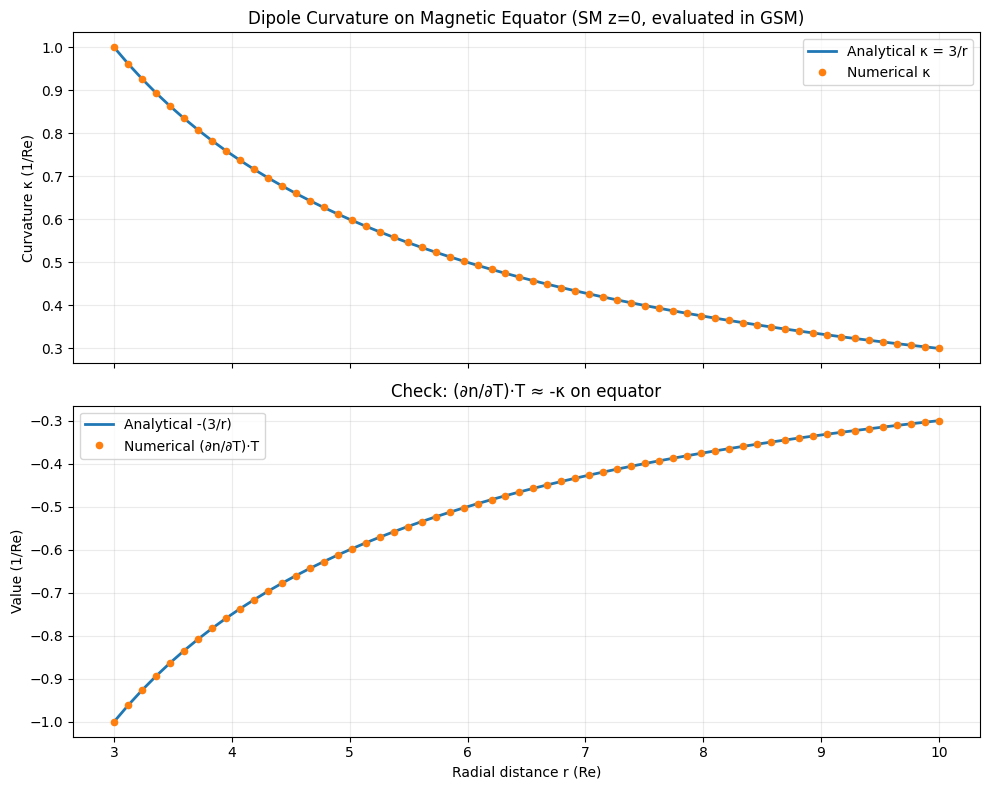

Analytical vs Numerical Comparison:
Max relative error in κ:        0.00%
Mean relative error in κ:       0.00%
Max relative error in -κ check: 0.00%
Mean error in -κ check:         0.00%


In [35]:
# Along the (magnetic) equator in SM: z_sm=0, y_sm=0, x_sm=-r
# Analytical curvature at equator for dipole field line: κ = 3 / r  (since r = L at λ=0)

r_eq = np.linspace(3, 10, 60)
x_eq_sm = -r_eq
y_eq_sm = np.zeros_like(r_eq)
z_eq_sm = np.zeros_like(r_eq)

# SM -> GSM
x_eq_gsm, y_eq_gsm, z_eq_gsm = smgsm_vectorized(x_eq_sm, y_eq_sm, z_eq_sm, j=+1)

# Compute derivatives and curvature numerically (use same machinery)
derivatives_eqline = field_line_directional_derivatives_vectorized(
    dipole_field_wrapper, None, ps, x_eq_gsm, y_eq_gsm, z_eq_gsm, delta=1e-5
)
curv_num, tors_num = get_curvature_torsion_from_derivatives(derivatives_eqline)

curv_ana = 3.0 / r_eq
dn_dT_T_eq = derivatives_eqline["dn_dT_T"]  # should be ~ -κ

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(r_eq, curv_ana, linewidth=2, label="Analytical κ = 3/r")
ax.plot(r_eq, curv_num, marker='o', linestyle='None', markersize=4.5, label="Numerical κ")
ax.set_ylabel("Curvature κ (1/Re)")
ax.set_title("Dipole Curvature on Magnetic Equator (SM z=0, evaluated in GSM)")
ax.grid(True, alpha=0.25)
ax.legend()

ax = axes[1]
ax.plot(r_eq, -curv_ana, linewidth=2, label="Analytical -(3/r)")
ax.plot(r_eq, dn_dT_T_eq, marker='o', linestyle='None', markersize=4.5, label="Numerical (∂n/∂T)·T")
ax.set_xlabel("Radial distance r (Re)")
ax.set_ylabel("Value (1/Re)")
ax.set_title("Check: (∂n/∂T)·T ≈ -κ on equator")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# Quantitative comparison
curv_rel_err = np.abs(curv_num - curv_ana) / curv_ana
relation_rel_err = np.abs(dn_dT_T_eq + curv_num) / np.maximum(np.abs(curv_num), 1e-30)

print("Analytical vs Numerical Comparison:")
print("=" * 60)
print(f"Max relative error in κ:        {np.nanmax(curv_rel_err)*100:.2f}%")
print(f"Mean relative error in κ:       {np.nanmean(curv_rel_err)*100:.2f}%")
print(f"Max relative error in -κ check: {np.nanmax(relation_rel_err)*100:.2f}%")
print(f"Mean error in -κ check:         {np.nanmean(relation_rel_err)*100:.2f}%")


 ## Summary Figure (text-only; keep intent, update κ=3/r)

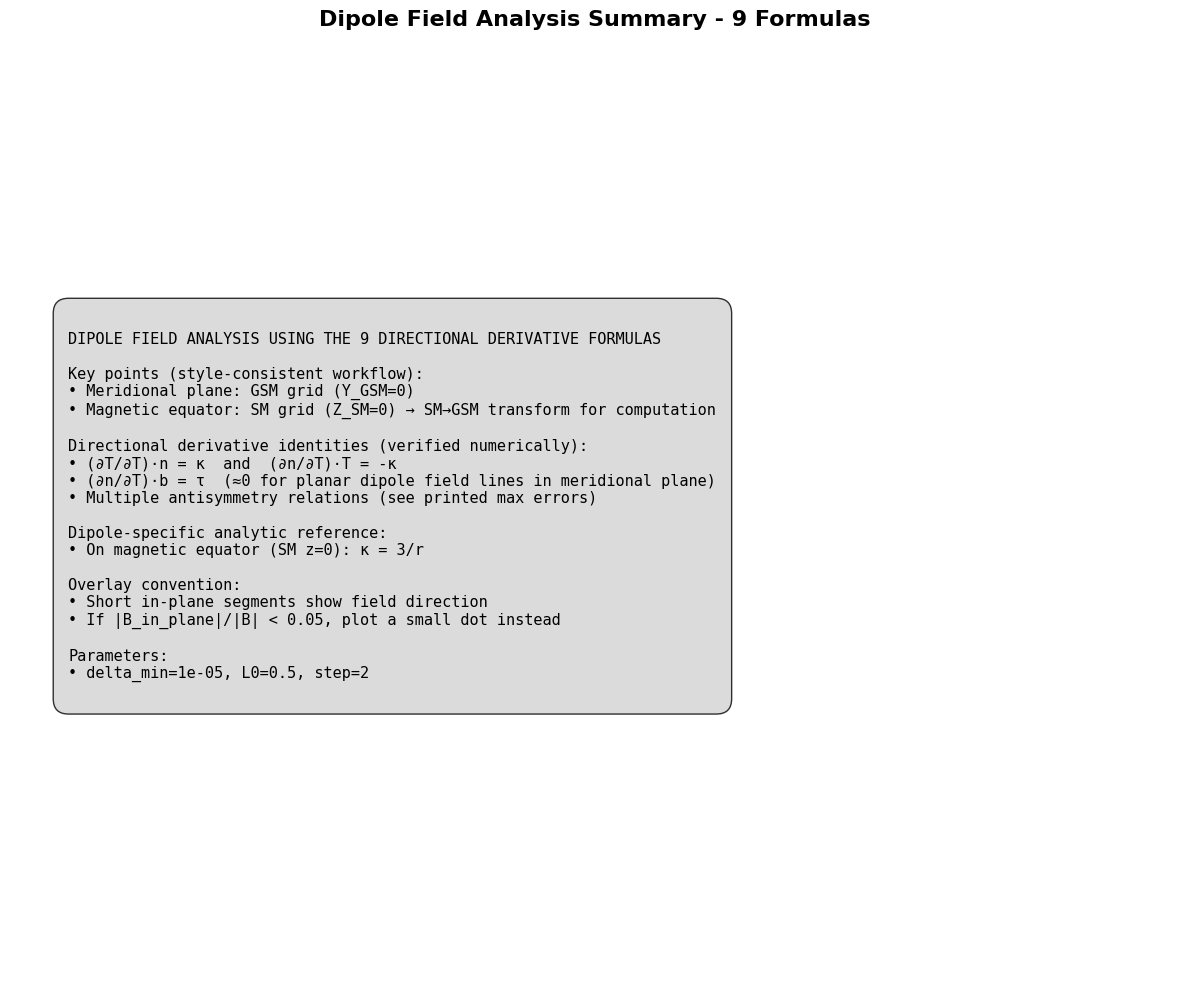

In [36]:
fig, ax = plt.subplots(figsize=(12, 10))
summary_text = f"""
DIPOLE FIELD ANALYSIS USING THE 9 DIRECTIONAL DERIVATIVE FORMULAS

Key points (style-consistent workflow):
• Meridional plane: GSM grid (Y_GSM=0)
• Magnetic equator: SM grid (Z_SM=0) → SM→GSM transform for computation

Directional derivative identities (verified numerically):
• (∂T/∂T)·n = κ  and  (∂n/∂T)·T = -κ
• (∂n/∂T)·b = τ  (≈0 for planar dipole field lines in meridional plane)
• Multiple antisymmetry relations (see printed max errors)

Dipole-specific analytic reference:
• On magnetic equator (SM z=0): κ = 3/r

Overlay convention:
• Short in-plane segments show field direction
• If |B_in_plane|/|B| < {perp_thresh}, plot a small dot instead

Parameters:
• delta_min={delta_min}, L0={L0}, step={step}
"""

ax.text(
    0.05, 0.5, summary_text,
    transform=ax.transAxes, fontsize=11,
    va='center', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=1', facecolor='lightgray', alpha=0.8)
)
ax.axis('off')
ax.set_title('Dipole Field Analysis Summary - 9 Formulas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()